In [1]:
import numpy as np

A = np.array([
    [12, 5, 8, 20],
    [7, 15, 3, 11],
    [25, 9, 18, 6],
    [10, 14, 2, 16]
])

mean = np.mean(A, axis=1)

result = (A > mean[:, None]).astype(int)

print("Row means:", mean)
print("Binary matrix:")
print(result)

count = np.sum(result, axis=1)

print("Count:", count)
print("Maximum count:", np.max(count))
print("Rows:", np.where(count == np.max(count))[0] + 1)

Row means: [11.25  9.   14.5  10.5 ]
Binary matrix:
[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]
Count: [2 2 2 2]
Maximum count: 2
Rows: [1 2 3 4]


In [2]:
import numpy as np

X = np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
])

mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

print("Mean:", mean)
print("Standard deviation:", std)

outlier = np.abs(X - mean) > 2 * std

print("Outliers:")
print(outlier)

median = np.median(X, axis=0)

new_X = X.copy()
new_X[outlier] = np.broadcast_to(median, X.shape)[outlier]

print("After replacing outliers:")
print(new_X)

Mean: [ 12.5        173.           6.83333333]
Standard deviation: [  1.70782513 146.31017281   1.34370962]
Outliers:
[[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]
After replacing outliers:
[[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 109   6]
 [ 14 108   8]
 [ 15 115   9]]


In [15]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A','B','C','D','E','F','G','H'],
    'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender': ['F','M','F','M','M','F','F','M'],
    'Marks': [85,72,91,65,78,88,95,70],
    'Attendance': [92,81,96,72,85,90,98,75]
})
print("Average marks:")
print(df.groupby('Department')['Marks'].mean())
print("\nDepartment and Gender average:")
print(df.groupby(['Department','Gender'])['Marks'].mean())
print("\nHighest marks:")
print(df.loc[df.groupby('Department')['Marks'].idxmax(),
            ['Department','Student','Marks']])
avg = df.groupby('Department')['Marks'].transform('mean')

print("\nAbove department average:")
print(df[df['Marks'] > avg][['Student','Department','Marks']])
attendance = df.groupby('Department')['Attendance'].mean()

print("\nAverage attendance:")
print(attendance)

print("Highest attendance department:", attendance.idxmax())

Average marks:
Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64

Department and Gender average:
Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64

Highest marks:
  Department Student  Marks
6        CSE       G     95
2        ECE       C     91

Above department average:
  Student Department  Marks
0       A        CSE     85
2       C        ECE     91
5       F        ECE     88
6       G        CSE     95

Average attendance:
Department
CSE    89.00
ECE    83.25
Name: Attendance, dtype: float64
Highest attendance department: CSE


In [14]:
import pandas as pd

df = pd.DataFrame({
    'ID': [101,102,103,101,104,102,105],
    'Name': ['A','B','C','A','D','B','E'],
    'Age': [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]
})
duplicate = df[df['ID'].duplicated(keep=False)]

print("Duplicated IDs:")
print(duplicate['ID'].unique())
check = df.groupby('ID').apply(
    lambda x: x.drop(columns='ID').nunique().max() == 1
)

print("\nAre records identical?")
print(check)
clean = df.loc[df.groupby('ID')['Score'].idxmax()]

clean = clean.sort_values('ID').reset_index(drop=True)

print("\nClean dataframe:")
print(clean)
removed = len(df) - len(clean)

print("\nRecords removed:", removed)

Duplicated IDs:
[101 102]

Are records identical?
ID
101    False
102     True
103     True
104     True
105     True
dtype: bool

Clean dataframe:
    ID Name  Age  Score
0  101    A   20     85
1  102    B   21     75
2  103    C   22     90
3  104    D   23     88
4  105    E   24     92

Records removed: 2


/tmp/ipykernel_1222/161037751.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  check = df.groupby('ID').apply(


In [13]:
import pandas as pd

df = pd.DataFrame({
    'Date': [
        '2026-01-01',
        '2026-01-02',
        '2026-01-04',
        '2026-01-05',
        '2026-01-08',
        '2026-01-09'
    ],
    'Sales': [100,120,150,130,180,200]
})

df['Date'] = pd.to_datetime(df['Date'])

df = df.set_index('Date')
dates = pd.date_range(df.index.min(), df.index.max())

missing = dates.difference(df.index)

print("Missing dates:")
print(missing)

df = df.reindex(dates)
df['Rolling_Avg'] = df['Sales'].rolling(3, min_periods=1).mean()

print("\nData:")
print(df)
date = df['Rolling_Avg'].idxmax()

print("\nMaximum rolling average date:", date)

Missing dates:
DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[ns]', freq=None)

Data:
            Sales  Rolling_Avg
2026-01-01  100.0        100.0
2026-01-02  120.0        110.0
2026-01-03    NaN        110.0
2026-01-04  150.0        135.0
2026-01-05  130.0        140.0
2026-01-06    NaN        140.0
2026-01-07    NaN        130.0
2026-01-08  180.0        180.0
2026-01-09  200.0        190.0

Maximum rolling average date: 2026-01-09 00:00:00


In [12]:
import numpy as np

P = np.array([
    [1, 2],
    [4, 6],
    [7, 3],
    [2, 8],
    [9, 5]
])
diff = P[:, None, :] - P[None, :, :]

D = np.sqrt(np.sum(diff ** 2, axis=2))

print("Distance matrix:")
print(D)
pos = np.unravel_index(np.argmax(D), D.shape)

print("\nMaximum distance:", D[pos])
print("Points:", pos[0] + 1, "and", pos[1] + 1)

Distance matrix:
[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]

Maximum distance: 8.54400374531753
Points: 1 and 5


ZIP file extracted successfully!

Number of CSV files found: 10
06_heart_disease.csv
05_diabetes.csv
10_sales.csv
09_mall_customers.csv
08_wine_quality.csv
07_student_performance.csv
03_housing.csv
02_iris.csv
04_weather.csv
01_titanic.csv


DATASET: 06_heart_disease.csv

1. Dataset Shape:
(15, 5)

2. First 5 Rows:


,age,cholesterol,blood_pressure,max_heart_rate,disease
0,29,180,120,172,0
1,34,195,125,168,0
2,41,210,130,160,0
3,48,245,140,150,1
4,52,230,135,145,1



3. Column Names:
['age', 'cholesterol', 'blood_pressure', 'max_heart_rate', 'disease']

4. Data Types:
age               int64
cholesterol       int64
blood_pressure    int64
max_heart_rate    int64
disease           int64
dtype: object

5. Missing Values:
age               0
cholesterol       0
blood_pressure    0
max_heart_rate    0
disease           0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,age,cholesterol,blood_pressure,max_heart_rate,disease
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,49.400000,232.666667,135.733333,151.933333,0.533333
std,10.966182,34.375379,10.780052,16.232536,0.516398
min,29.000000,180.000000,120.000000,125.000000,0.000000
25%,42.000000,207.500000,127.000000,139.000000,0.000000
50%,50.000000,230.000000,135.000000,150.000000,1.000000
75%,57.500000,257.500000,143.500000,166.500000,1.000000
max,67.000000,290.000000,155.000000,175.000000,1.000000


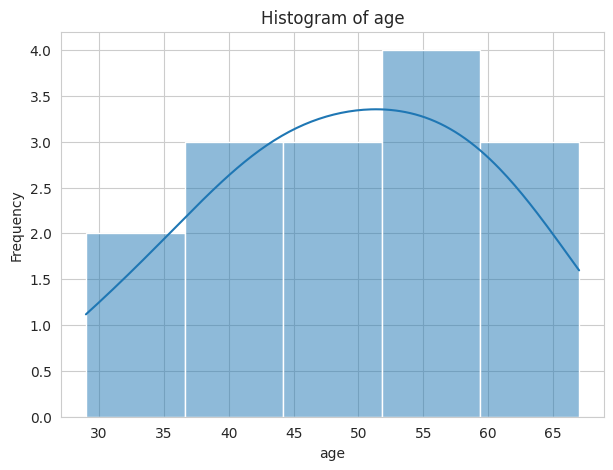

Insight:
The histogram shows the distribution of age and helps identify the spread of the data.


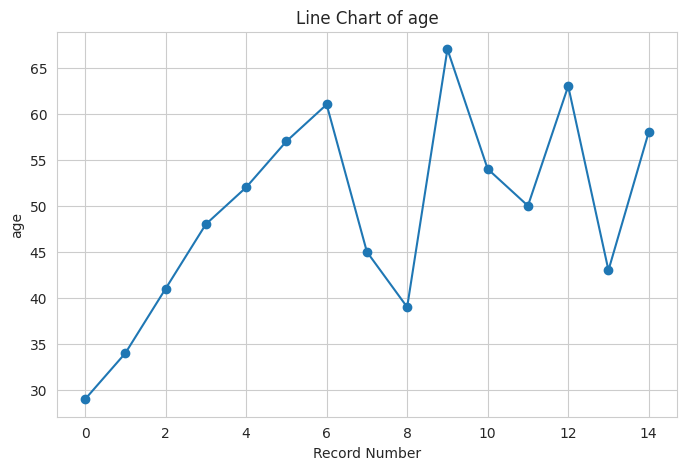

Insight:
The line chart shows how age changes across the observations.


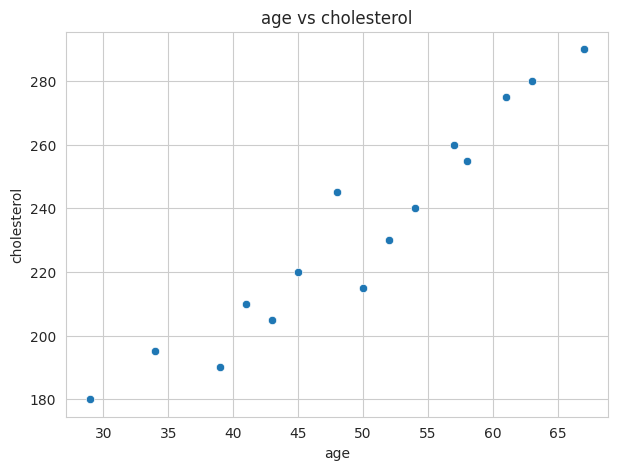

Insight:
The scatter plot shows the relationship between age and cholesterol.


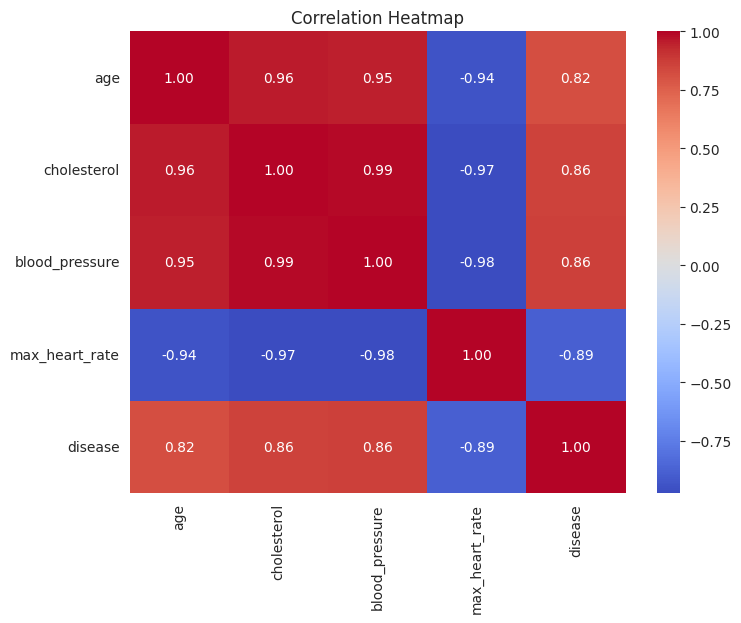

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 5)

EDA completed for: 06_heart_disease.csv

----------------------------------------------------------------------


DATASET: 05_diabetes.csv

1. Dataset Shape:
(15, 5)

2. First 5 Rows:


,pregnancies,glucose,bmi,age,outcome
0,1,85,22.1,25,0
1,4,120,28.5,35,1
2,0,95,24.2,28,0
3,3,140,31.0,45,1
4,2,110,26.4,31,0



3. Column Names:
['pregnancies', 'glucose', 'bmi', 'age', 'outcome']

4. Data Types:
pregnancies      int64
glucose          int64
bmi            float64
age              int64
outcome          int64
dtype: object

5. Missing Values:
pregnancies    0
glucose        0
bmi            0
age            0
outcome        0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,pregnancies,glucose,bmi,age,outcome
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,3.400000,130.000000,28.766667,40.933333,0.600000
std,2.472708,30.647769,4.353269,12.418113,0.507093
min,0.000000,85.000000,21.800000,24.000000,0.000000
25%,1.500000,105.000000,25.300000,30.000000,0.000000
50%,3.000000,130.000000,29.400000,42.000000,1.000000
75%,5.000000,152.500000,32.150000,51.000000,1.000000
max,8.000000,180.000000,35.100000,60.000000,1.000000


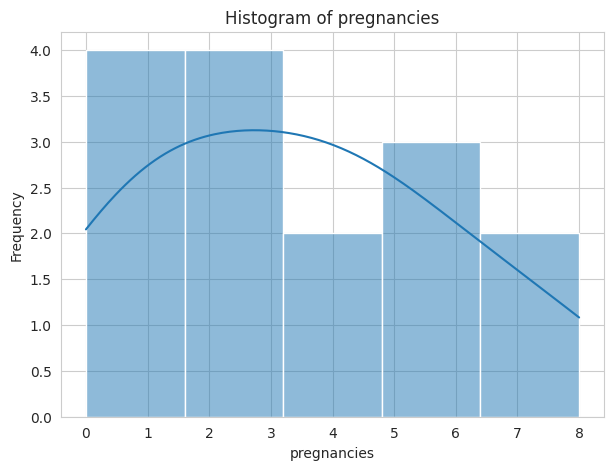

Insight:
The histogram shows the distribution of pregnancies and helps identify the spread of the data.


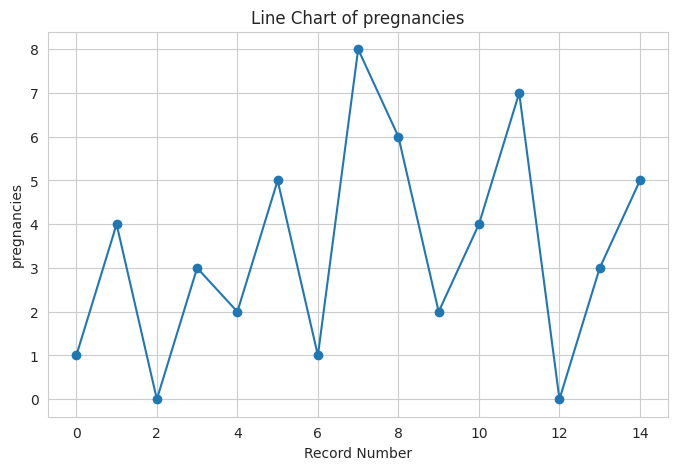

Insight:
The line chart shows how pregnancies changes across the observations.


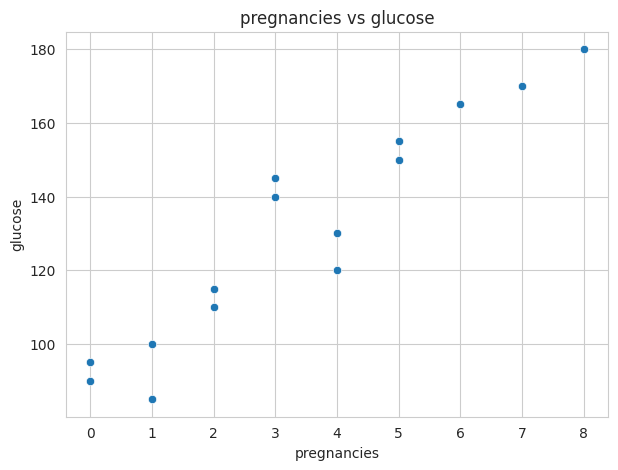

Insight:
The scatter plot shows the relationship between pregnancies and glucose.


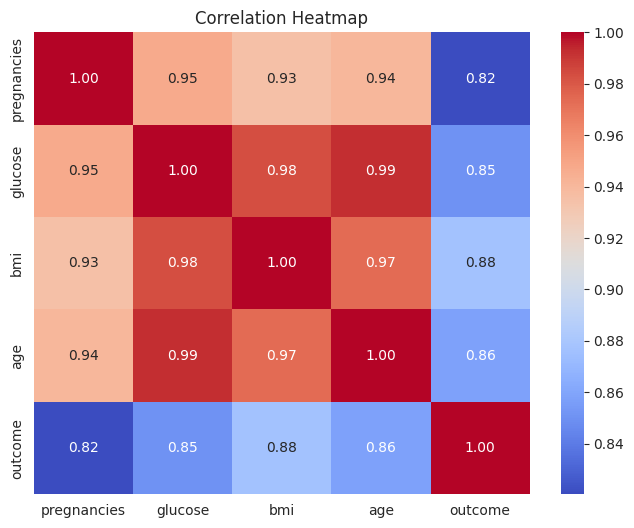

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 5)

EDA completed for: 05_diabetes.csv

----------------------------------------------------------------------


DATASET: 10_sales.csv

1. Dataset Shape:
(15, 4)

2. First 5 Rows:


,date,sales,units,advertising
0,2026-02-01,120,12,20
1,2026-02-02,135,14,22
2,2026-02-03,128,13,21
3,2026-02-04,150,15,25
4,2026-02-05,160,16,27



3. Column Names:
['date', 'sales', 'units', 'advertising']

4. Data Types:
date           object
sales           int64
units           int64
advertising     int64
dtype: object

5. Missing Values:
date           0
sales          0
units          0
advertising    0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,sales,units,advertising
count,15.000000,15.000000,15.000000
mean,175.066667,17.533333,29.333333
std,35.267279,3.661902,6.275424
min,120.000000,12.000000,20.000000
25%,147.500000,14.500000,24.500000
50%,175.000000,17.000000,29.000000
75%,201.500000,19.500000,34.000000
max,230.000000,24.000000,40.000000


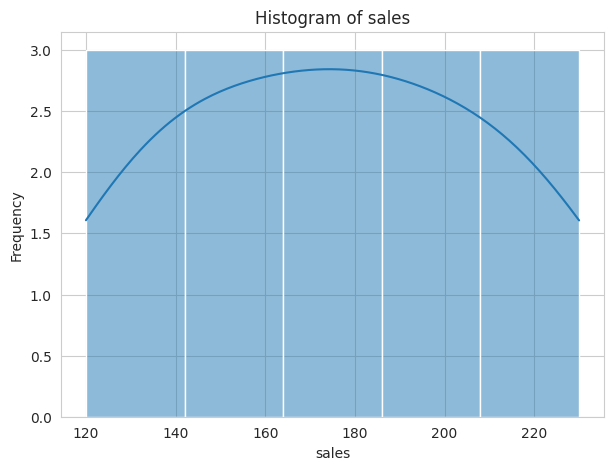

Insight:
The histogram shows the distribution of sales and helps identify the spread of the data.


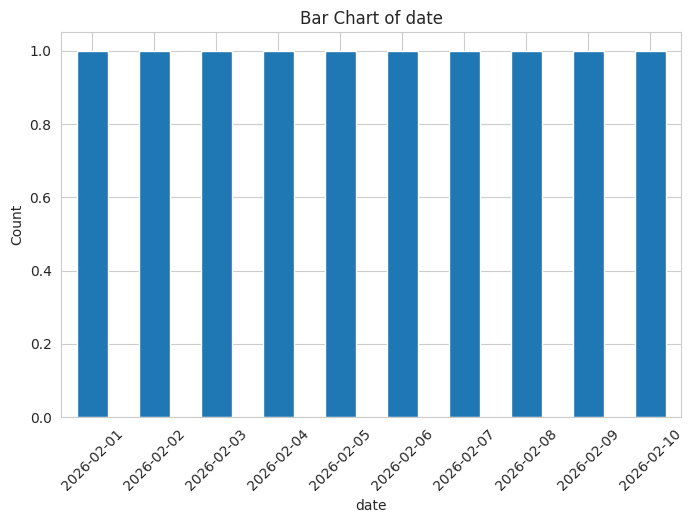

Insight:
The bar chart shows the frequency of the different categories in date.


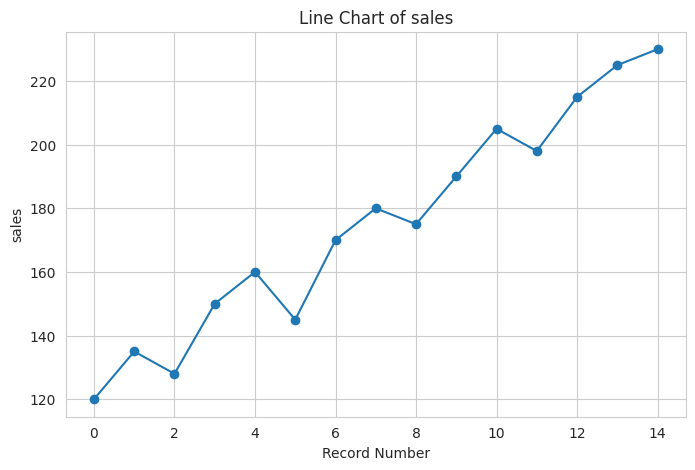

Insight:
The line chart shows how sales changes across the observations.


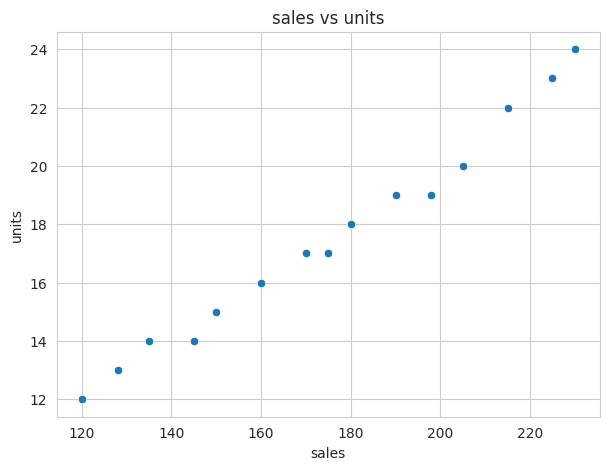

Insight:
The scatter plot shows the relationship between sales and units.


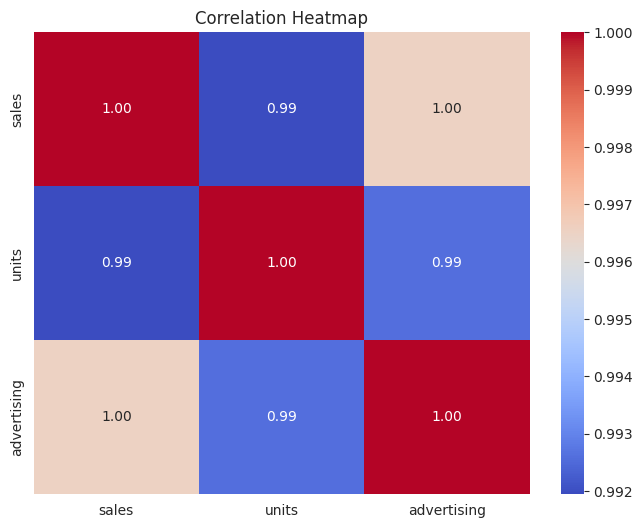

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 4)

EDA completed for: 10_sales.csv

----------------------------------------------------------------------


DATASET: 09_mall_customers.csv

1. Dataset Shape:
(15, 4)

2. First 5 Rows:


,customer_id,age,annual_income,spending_score
0,1,19,15,39
1,2,21,18,81
2,3,23,20,77
3,4,25,25,66
4,5,28,30,56



3. Column Names:
['customer_id', 'age', 'annual_income', 'spending_score']

4. Data Types:
customer_id       int64
age               int64
annual_income     int64
spending_score    int64
dtype: object

5. Missing Values:
customer_id       0
age               0
annual_income     0
spending_score    0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,customer_id,age,annual_income,spending_score
count,15.000000,15.000000,15.000000,15.000000
mean,8.000000,34.200000,41.133333,55.133333
std,4.472136,10.557327,19.193997,17.278668
min,1.000000,19.000000,15.000000,25.000000
25%,4.500000,26.500000,27.500000,41.000000
50%,8.000000,33.000000,40.000000,56.000000
75%,11.500000,41.000000,52.500000,68.000000
max,15.000000,54.000000,80.000000,81.000000


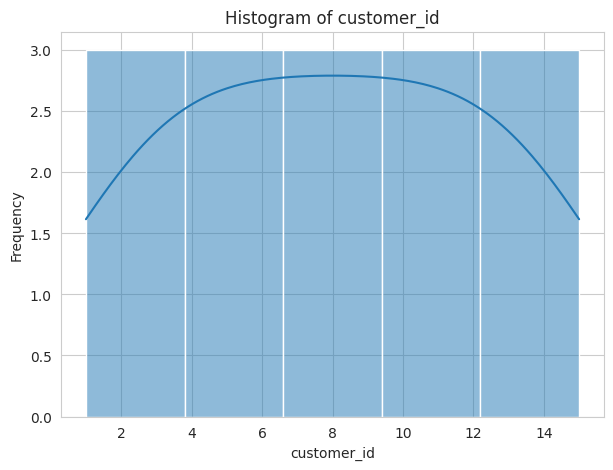

Insight:
The histogram shows the distribution of customer_id and helps identify the spread of the data.


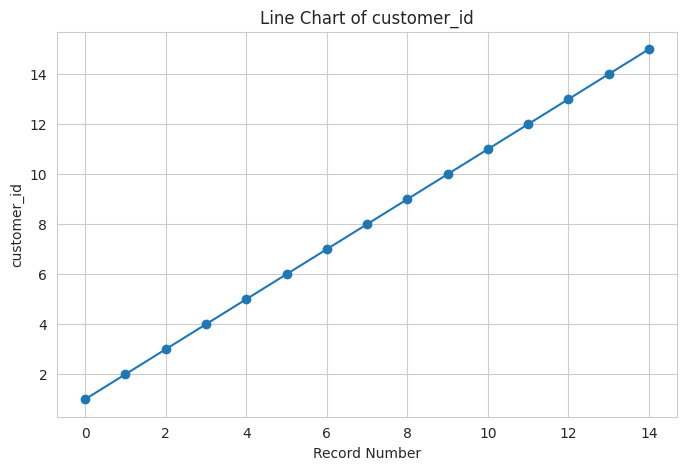

Insight:
The line chart shows how customer_id changes across the observations.


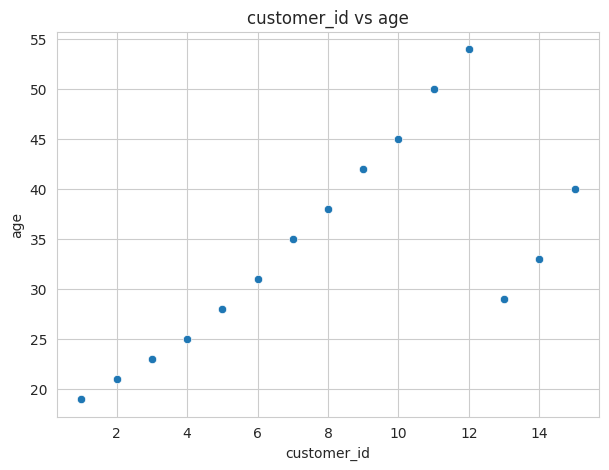

Insight:
The scatter plot shows the relationship between customer_id and age.


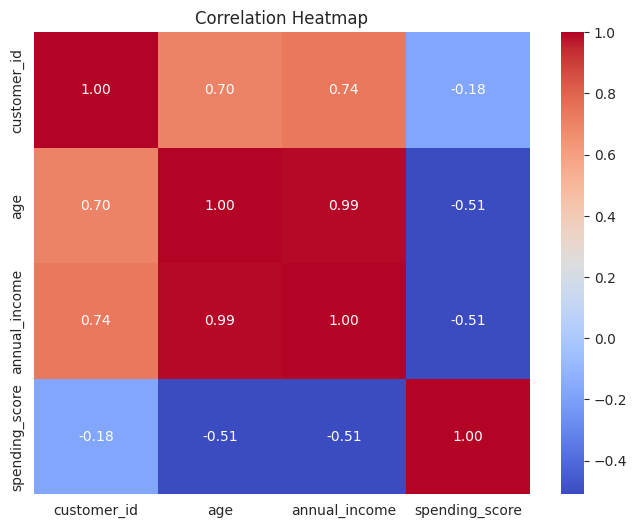

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 4)

EDA completed for: 09_mall_customers.csv

----------------------------------------------------------------------


DATASET: 08_wine_quality.csv

1. Dataset Shape:
(15, 5)

2. First 5 Rows:


,alcohol,acidity,sugar,pH,quality
0,9.5,7.2,1.8,3.4,5
1,10.2,6.8,2.1,3.3,5
2,10.8,7.0,2.5,3.2,6
3,11.1,6.5,2.0,3.1,6
4,11.5,6.2,2.8,3.0,7



3. Column Names:
['alcohol', 'acidity', 'sugar', 'pH', 'quality']

4. Data Types:
alcohol    float64
acidity    float64
sugar      float64
pH         float64
quality      int64
dtype: object

5. Missing Values:
alcohol    0
acidity    0
sugar      0
pH         0
quality    0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,alcohol,acidity,sugar,pH,quality
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,11.626667,6.140000,2.453333,3.186667,6.800000
std,1.266867,0.721902,0.403320,0.135576,1.264911
min,9.500000,5.000000,1.800000,3.000000,5.000000
25%,10.650000,5.600000,2.150000,3.100000,6.000000
50%,11.800000,6.100000,2.500000,3.200000,7.000000
75%,12.650000,6.750000,2.750000,3.300000,8.000000
max,13.500000,7.200000,3.100000,3.400000,9.000000


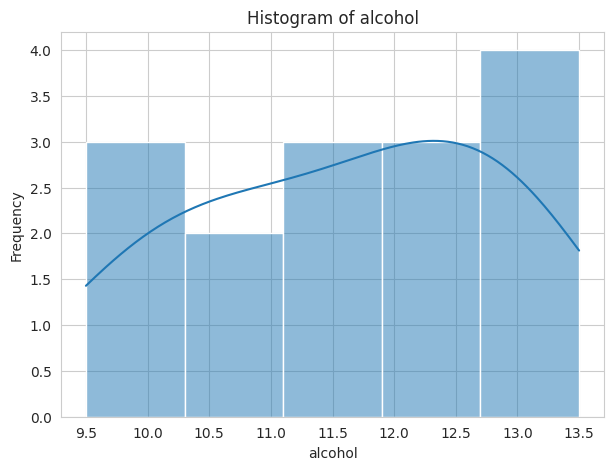

Insight:
The histogram shows the distribution of alcohol and helps identify the spread of the data.


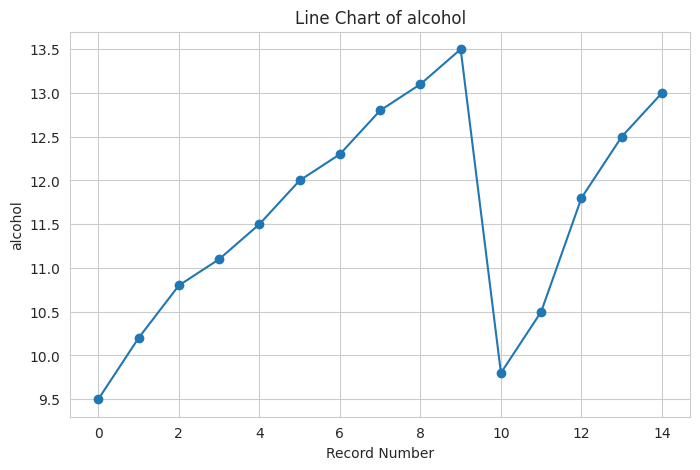

Insight:
The line chart shows how alcohol changes across the observations.


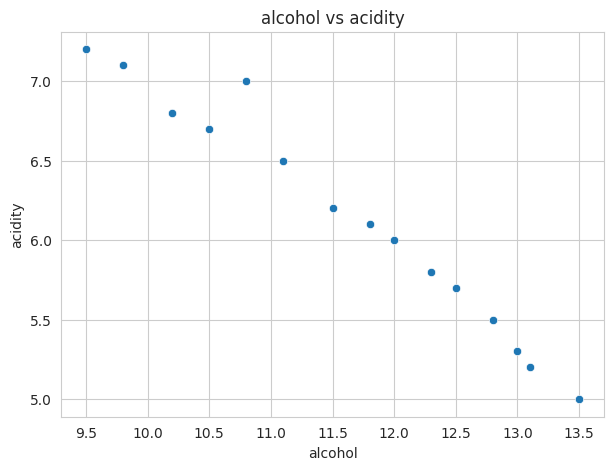

Insight:
The scatter plot shows the relationship between alcohol and acidity.


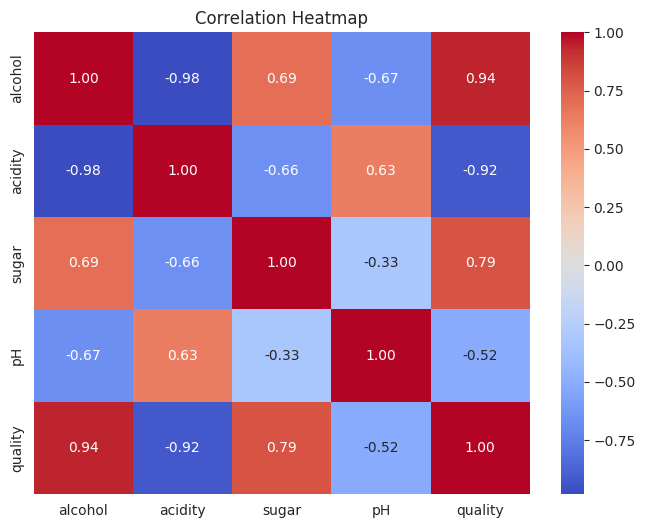

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 5)

EDA completed for: 08_wine_quality.csv

----------------------------------------------------------------------


DATASET: 07_student_performance.csv

1. Dataset Shape:
(15, 4)

2. First 5 Rows:


,study_hours,attendance,assignments,marks
0,2,75,60,55
1,3,82,70,62
2,1,68,55,48
3,5,90,88,78
4,4,88,82,72



3. Column Names:
['study_hours', 'attendance', 'assignments', 'marks']

4. Data Types:
study_hours    int64
attendance     int64
assignments    int64
marks          int64
dtype: object

5. Missing Values:
study_hours    0
attendance     0
assignments    0
marks          0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,study_hours,attendance,assignments,marks
count,15.000000,15.000000,15.000000,15.000000
mean,4.266667,85.866667,79.266667,72.333333
std,2.250926,10.384512,15.970807,16.438920
min,1.000000,65.000000,50.000000,45.000000
25%,2.500000,80.500000,67.500000,60.000000
50%,4.000000,88.000000,82.000000,72.000000
75%,6.000000,94.500000,92.500000,86.500000
max,8.000000,98.000000,99.000000,96.000000


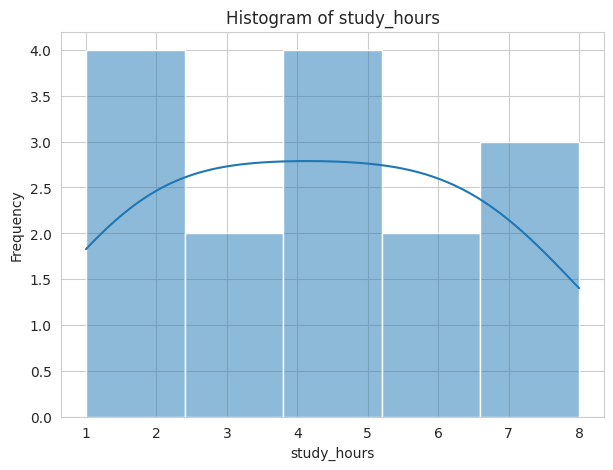

Insight:
The histogram shows the distribution of study_hours and helps identify the spread of the data.


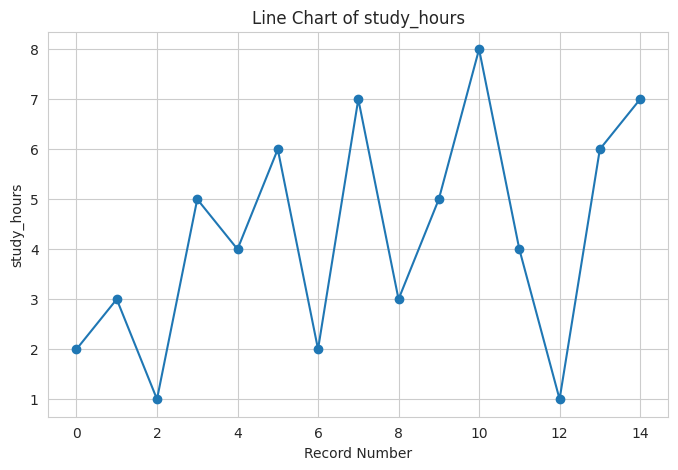

Insight:
The line chart shows how study_hours changes across the observations.


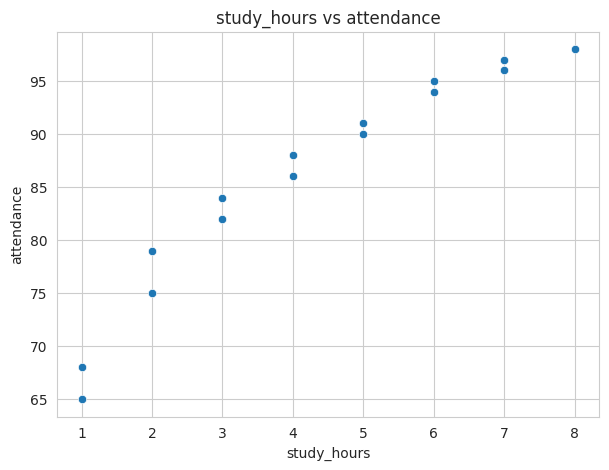

Insight:
The scatter plot shows the relationship between study_hours and attendance.


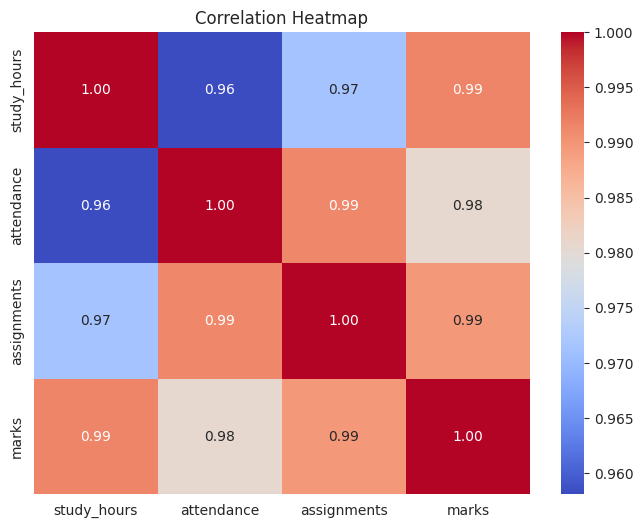

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 4)

EDA completed for: 07_student_performance.csv

----------------------------------------------------------------------


DATASET: 03_housing.csv

1. Dataset Shape:
(15, 5)

2. First 5 Rows:


,area_sqft,bedrooms,bathrooms,age_years,price
0,850,2,1,20,45
1,900,2,1,18,48
2,1100,2,2,15,58
3,1200,3,2,12,65
4,1350,3,2,10,72



3. Column Names:
['area_sqft', 'bedrooms', 'bathrooms', 'age_years', 'price']

4. Data Types:
area_sqft    int64
bedrooms     int64
bathrooms    int64
age_years    int64
price        int64
dtype: object

5. Missing Values:
area_sqft    0
bedrooms     0
bathrooms    0
age_years    0
price        0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,area_sqft,bedrooms,bathrooms,age_years,price
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,1870.000000,3.466667,2.733333,7.800000,110.333333
std,758.946638,1.060099,1.162919,6.037975,54.575854
min,850.000000,2.000000,1.000000,1.000000,45.000000
25%,1275.000000,3.000000,2.000000,3.500000,68.500000
50%,1750.000000,3.000000,3.000000,6.000000,96.000000
75%,2400.000000,4.000000,3.500000,11.000000,142.500000
max,3200.000000,5.000000,5.000000,20.000000,220.000000


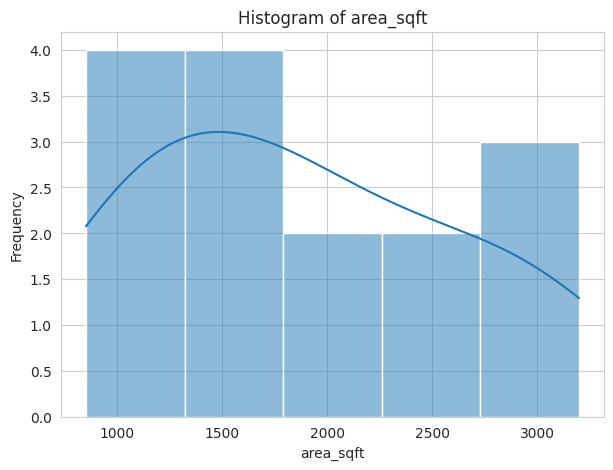

Insight:
The histogram shows the distribution of area_sqft and helps identify the spread of the data.


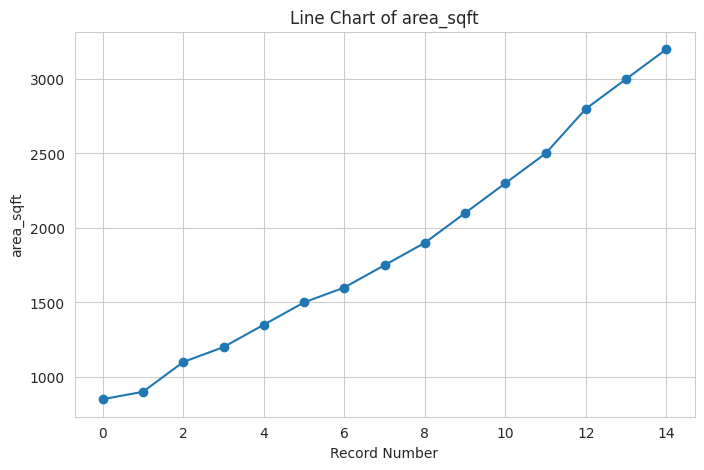

Insight:
The line chart shows how area_sqft changes across the observations.


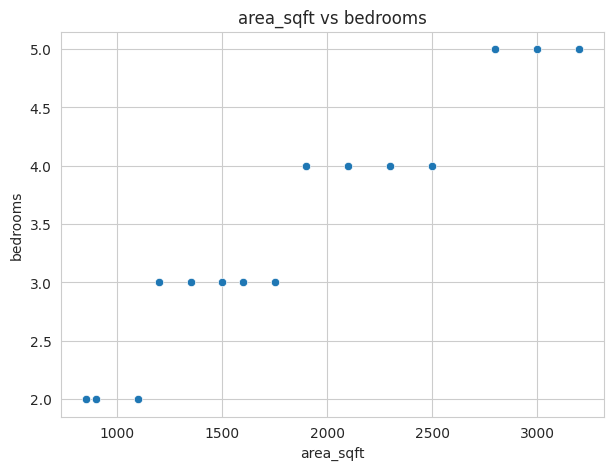

Insight:
The scatter plot shows the relationship between area_sqft and bedrooms.


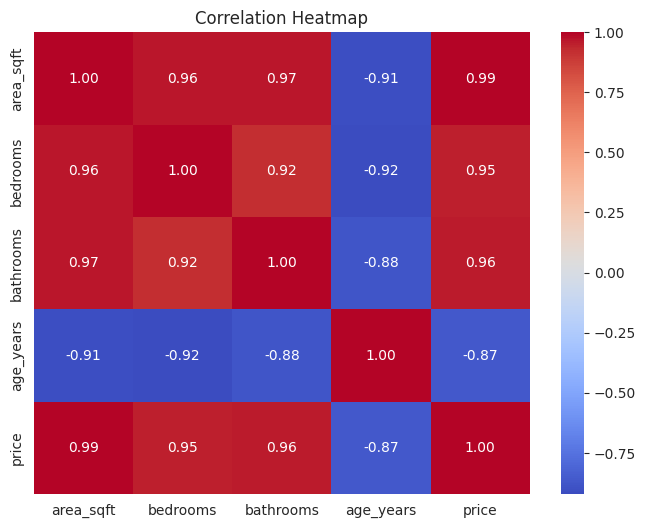

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 5)

EDA completed for: 03_housing.csv

----------------------------------------------------------------------


DATASET: 02_iris.csv

1. Dataset Shape:
(15, 5)

2. First 5 Rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,5.0,3.6,1.4,0.2,setosa
4,5.4,3.9,1.7,0.4,setosa



3. Column Names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

4. Data Types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

5. Missing Values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,15.000000,15.000000,15.000000,15.000000
mean,5.873333,3.086667,3.846667,1.253333
std,0.759198,0.392550,1.862359,0.812287
min,4.700000,2.300000,1.300000,0.200000
25%,5.250000,2.850000,1.550000,0.300000
50%,5.800000,3.000000,4.500000,1.500000
75%,6.450000,3.250000,5.350000,1.850000
max,7.100000,3.900000,6.000000,2.500000


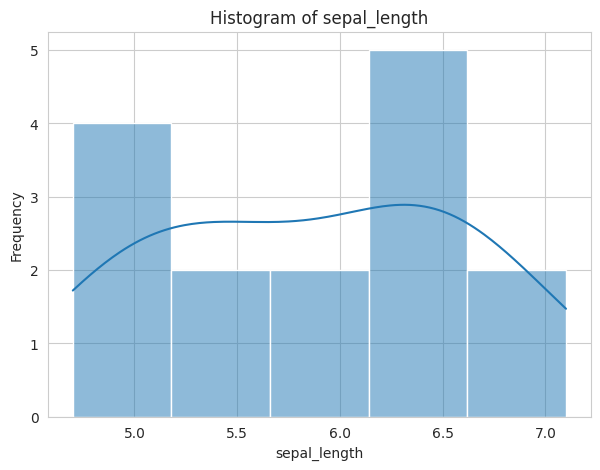

Insight:
The histogram shows the distribution of sepal_length and helps identify the spread of the data.


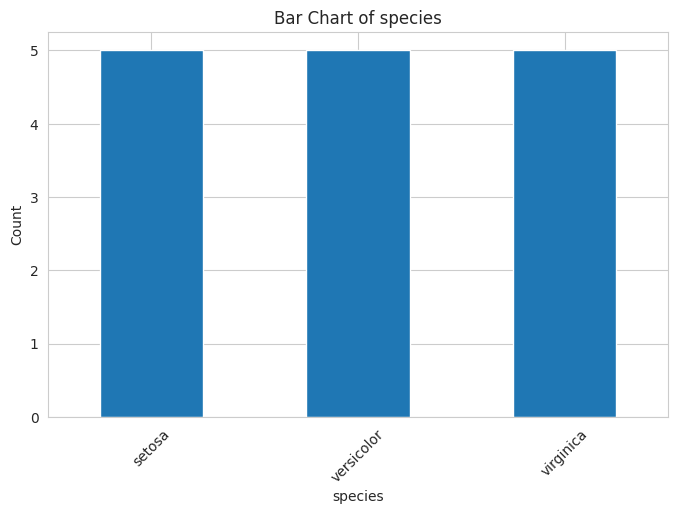

Insight:
The bar chart shows the frequency of the different categories in species.


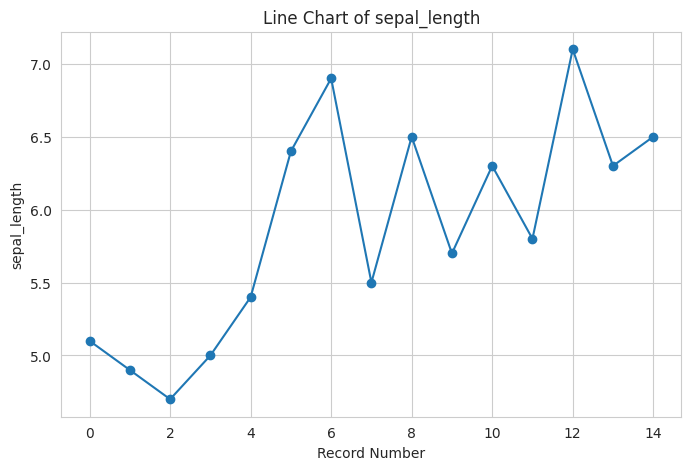

Insight:
The line chart shows how sepal_length changes across the observations.


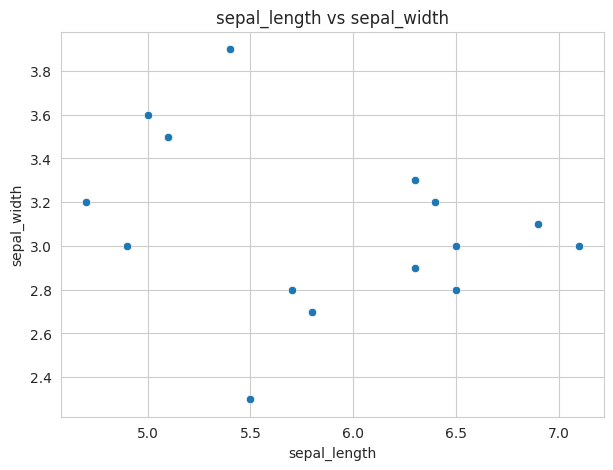

Insight:
The scatter plot shows the relationship between sepal_length and sepal_width.


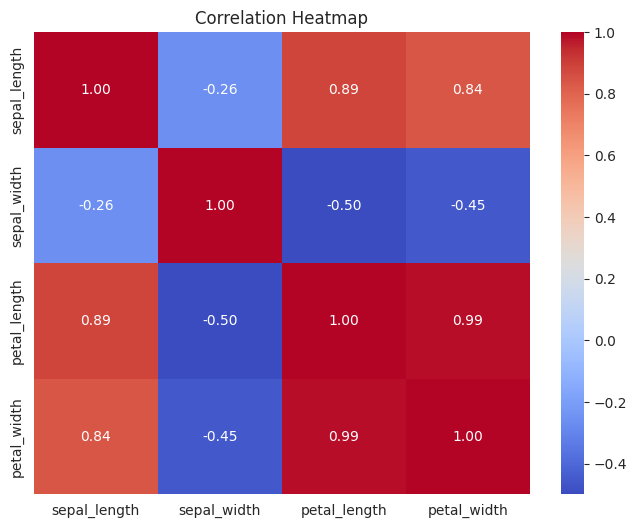

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 5)

EDA completed for: 02_iris.csv

----------------------------------------------------------------------


DATASET: 04_weather.csv

1. Dataset Shape:
(15, 4)

2. First 5 Rows:


,date,temperature,humidity,rainfall
0,2026-01-01,22,65,2
1,2026-01-02,24,62,0
2,2026-01-03,23,68,5
3,2026-01-04,25,60,0
4,2026-01-05,27,58,1



3. Column Names:
['date', 'temperature', 'humidity', 'rainfall']

4. Data Types:
date           object
temperature     int64
humidity        int64
rainfall        int64
dtype: object

5. Missing Values:
date           0
temperature    0
humidity       0
rainfall       0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,temperature,humidity,rainfall
count,15.000000,15.000000,15.000000
mean,25.800000,60.866667,2.133333
std,2.366432,5.423055,2.559762
min,22.000000,52.000000,0.000000
25%,24.000000,57.500000,0.000000
50%,26.000000,61.000000,1.000000
75%,27.500000,64.500000,3.500000
max,30.000000,70.000000,8.000000


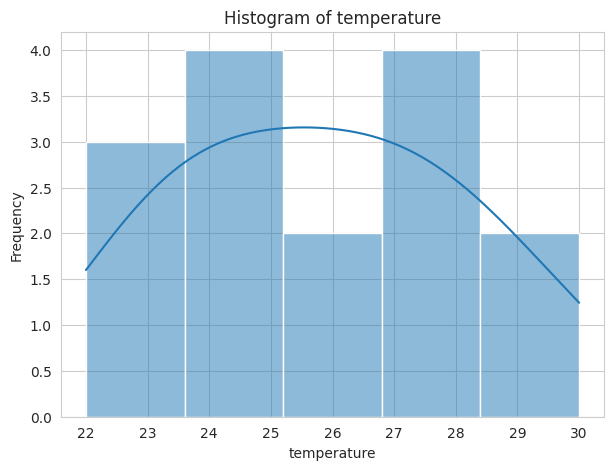

Insight:
The histogram shows the distribution of temperature and helps identify the spread of the data.


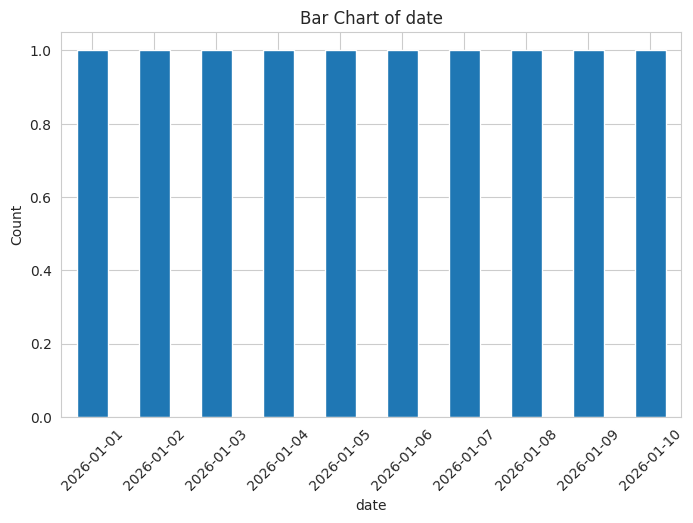

Insight:
The bar chart shows the frequency of the different categories in date.


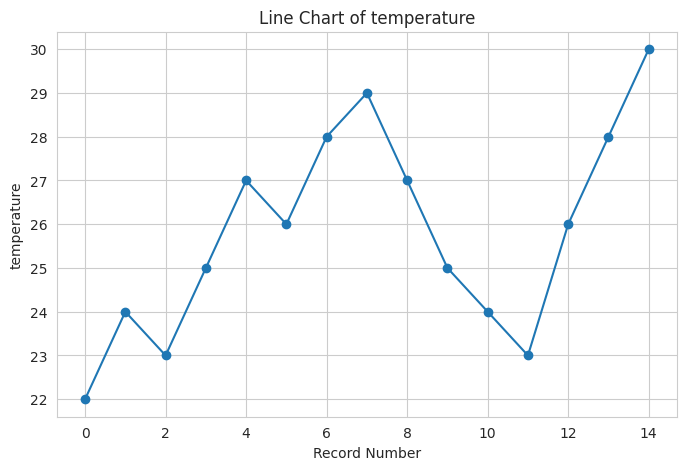

Insight:
The line chart shows how temperature changes across the observations.


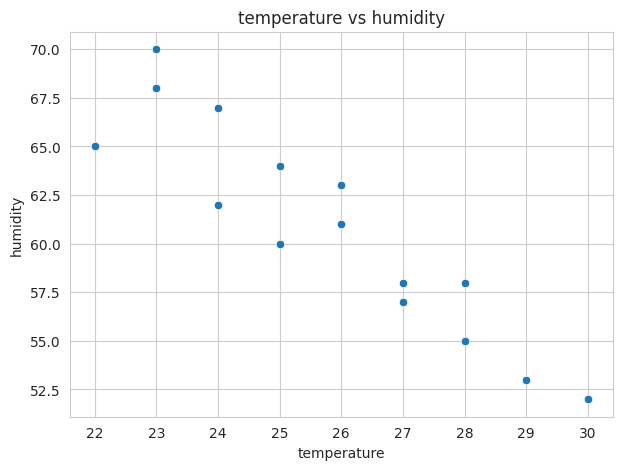

Insight:
The scatter plot shows the relationship between temperature and humidity.


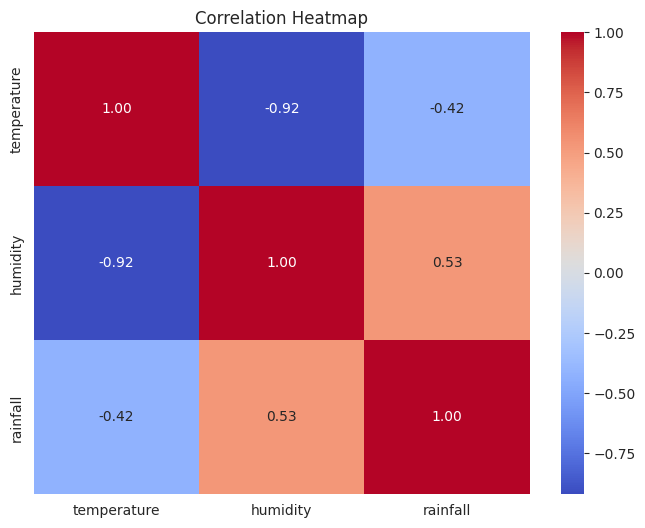

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(15, 4)

EDA completed for: 04_weather.csv

----------------------------------------------------------------------


DATASET: 01_titanic.csv

1. Dataset Shape:
(20, 6)

2. First 5 Rows:


,PassengerId,Survived,Pclass,Sex,Age,Fare
0,1,1,1,female,22,71
1,2,0,3,male,35,7
2,3,1,2,female,26,15
3,4,1,1,female,28,80
4,5,0,3,male,40,8



3. Column Names:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'Fare']

4. Data Types:
PassengerId     int64
Survived        int64
Pclass          int64
Sex            object
Age             int64
Fare            int64
dtype: object

5. Missing Values:
PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
Fare           0
dtype: int64

6. Duplicate Rows: 0

7. Missing Values After Cleaning:
0

8. Statistical Summary:


,PassengerId,Survived,Pclass,Age,Fare
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,0.550000,2.100000,30.950000,31.450000
std,5.91608,0.510418,0.852242,8.923505,28.193831
min,1.00000,0.000000,1.000000,18.000000,7.000000
25%,5.75000,0.000000,1.000000,24.750000,8.750000
50%,10.50000,1.000000,2.000000,29.500000,19.000000
75%,15.25000,1.000000,3.000000,36.500000,66.250000
max,20.00000,1.000000,3.000000,50.000000,80.000000


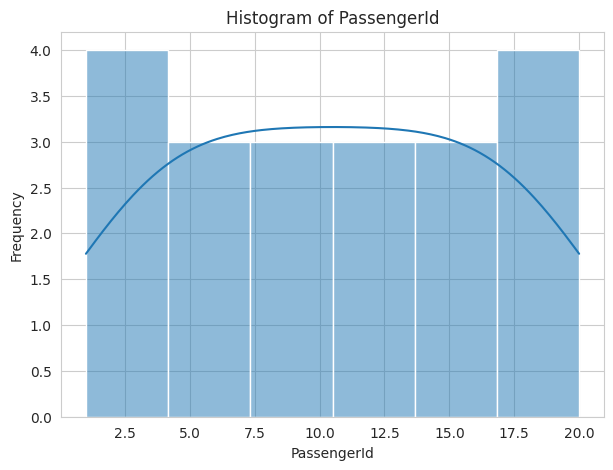

Insight:
The histogram shows the distribution of PassengerId and helps identify the spread of the data.


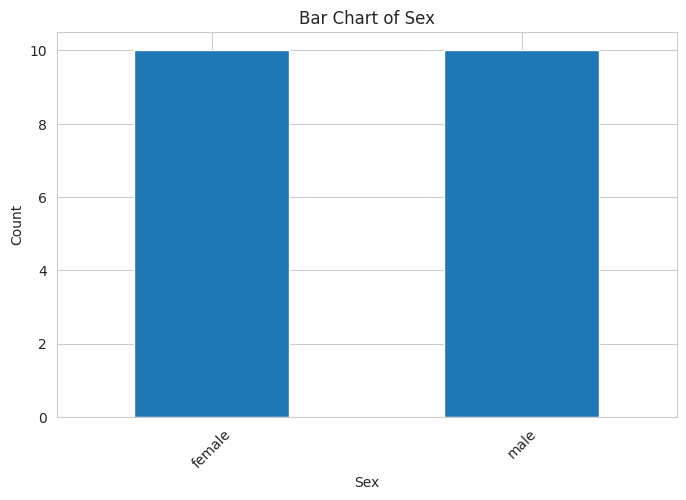

Insight:
The bar chart shows the frequency of the different categories in Sex.


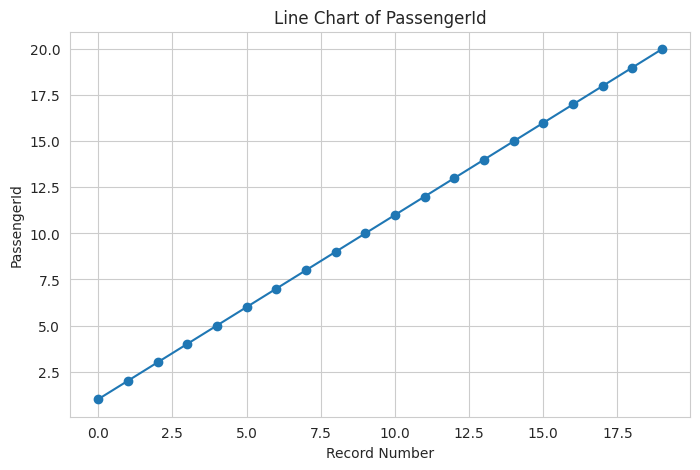

Insight:
The line chart shows how PassengerId changes across the observations.


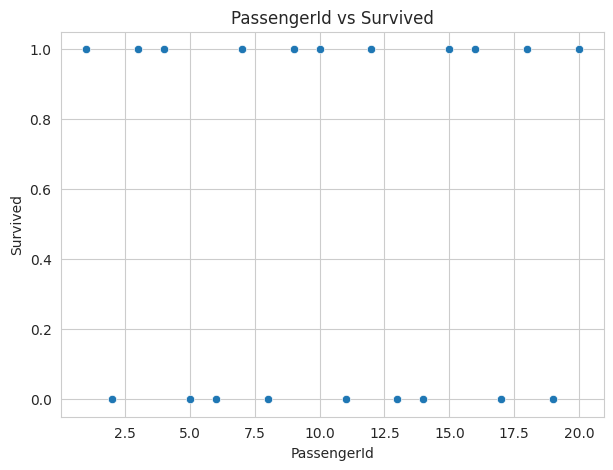

Insight:
The scatter plot shows the relationship between PassengerId and Survived.


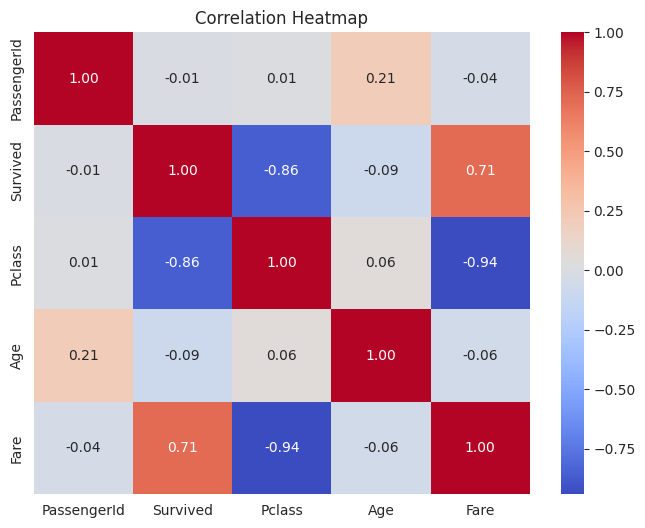

Insight:
The heatmap shows the correlation between numerical variables.

Final Dataset Shape After Cleaning:
(20, 6)

EDA completed for: 01_titanic.csv

----------------------------------------------------------------------



EDA COMPLETED FOR ALL DATASETS



In [18]:

# STEP 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

sns.set_style("whitegrid")

# STEP 2: Extract the ZIP file

zip_file = "/content/EDA_10_Datasets.zip"
extract_folder = "/content/datasets"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("ZIP file extracted successfully!")

# STEP 3: Find all CSV files

csv_files = []

for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("\nNumber of CSV files found:", len(csv_files))

for file in csv_files:
    print(os.path.basename(file))

# STEP 4: Perform EDA on each dataset

for file_path in csv_files[:10]:

    print("\n")
    print("=" * 70)
    print("DATASET:", os.path.basename(file_path))
    print("=" * 70)

    # Read dataset
    try:
        df = pd.read_csv(file_path)

    except:
        print("Could not read this file. Skipping...")
        continue

    # BASIC INFORMATION

    print("\n1. Dataset Shape:")
    print(df.shape)

    print("\n2. First 5 Rows:")
    display(df.head())

    print("\n3. Column Names:")
    print(df.columns.tolist())

    print("\n4. Data Types:")
    print(df.dtypes)

    # MISSING VALUES

    print("\n5. Missing Values:")
    print(df.isnull().sum())

    # REMOVE DUPLICATES

    duplicate_count = df.duplicated().sum()

    print("\n6. Duplicate Rows:", duplicate_count)

    df = df.drop_duplicates()
    # CLEAN MISSING VALUES

    numerical_columns = df.select_dtypes(
        include=np.number
    ).columns

    categorical_columns = df.select_dtypes(
        include="object"
    ).columns

    for column in numerical_columns:
        df[column] = df[column].fillna(df[column].median())

    for column in categorical_columns:

        if df[column].isnull().sum() > 0:

            if len(df[column].mode()) > 0:
                df[column] = df[column].fillna(
                    df[column].mode()[0]
                )


    print("\n7. Missing Values After Cleaning:")
    print(df.isnull().sum().sum())

    # STATISTICAL SUMMARY

    print("\n8. Statistical Summary:")

    if len(numerical_columns) > 0:
        display(df[numerical_columns].describe())

    # GRAPH 1 - HISTOGRAM

    if len(numerical_columns) > 0:

        column = numerical_columns[0]

        plt.figure(figsize=(7, 5))

        sns.histplot(
            df[column],
            kde=True
        )

        plt.title("Histogram of " + column)
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.show()

        print("Insight:")
        print(
            "The histogram shows the distribution of",
            column,
            "and helps identify the spread of the data."
        )

    # GRAPH 2 - BAR CHART

    if len(categorical_columns) > 0:

        column = categorical_columns[0]

        plt.figure(figsize=(8, 5))

        df[column].value_counts().head(10).plot(
            kind="bar"
        )

        plt.title("Bar Chart of " + column)
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.xticks(rotation=45)

        plt.show()

        print("Insight:")
        print(
            "The bar chart shows the frequency of the",
            "different categories in", column + "."
        )

    # GRAPH 3 - LINE CHART

    if len(numerical_columns) >= 1:

        column = numerical_columns[0]

        plt.figure(figsize=(8, 5))

        plt.plot(
            df[column].head(50).values,
            marker="o"
        )

        plt.title("Line Chart of " + column)
        plt.xlabel("Record Number")
        plt.ylabel(column)

        plt.show()

        print("Insight:")
        print(
            "The line chart shows how",
            column,
            "changes across the observations."
        )

    # GRAPH 4 - SCATTER PLOT

    if len(numerical_columns) >= 2:

        x = numerical_columns[0]
        y = numerical_columns[1]

        plt.figure(figsize=(7, 5))

        sns.scatterplot(
            data=df,
            x=x,
            y=y
        )

        plt.title(x + " vs " + y)
        plt.xlabel(x)
        plt.ylabel(y)

        plt.show()

        print("Insight:")
        print(
            "The scatter plot shows the relationship",
            "between", x, "and", y + "."
        )

    # GRAPH 5 - CORRELATION HEATMAP

    if len(numerical_columns) >= 2:

        plt.figure(figsize=(8, 6))

        correlation = df[numerical_columns].corr()

        sns.heatmap(
            correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )

        plt.title("Correlation Heatmap")

        plt.show()

        print("Insight:")
        print(
            "The heatmap shows the correlation between",
            "numerical variables."
        )

    # FINAL CLEANED DATASET

    print("\nFinal Dataset Shape After Cleaning:")
    print(df.shape)

    print("\nEDA completed for:",
          os.path.basename(file_path))

    print("\n" + "-" * 70)


print("\n\n")
print("EDA COMPLETED FOR ALL DATASETS")
print("")